# Split de los datos

## librerias usadas

In [1]:
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

En esta parte importamos las librerias que usaremos en nuestro split.

## Cargado de funciones

In [2]:
from funciones import crear_pipeline

## Cargado de datos

In [3]:
df_url='https://docs.google.com/spreadsheets/d/1NJiaIRABEh1mJrqzP6bAYBkhBruBwUUzplHdXViv9-g/export?format=csv'
df=pd.read_csv(df_url)

In [4]:
df.head()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


## Split de los datos

In [5]:
X=df.drop(columns=['Thyroid_Cancer_Risk','Patient_ID', 'Diagnosis'])
Y=df['Thyroid_Cancer_Risk']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y)

In [7]:
pipe = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr'), tipo="normal")

In [8]:
X_train_procesado= pipe.named_steps['preprocesador'].fit_transform(X_train)
feature_names = pipe.named_steps["preprocesador"].get_feature_names_out()
X_train_procesado = pd.DataFrame(X_train_procesado, columns=feature_names)

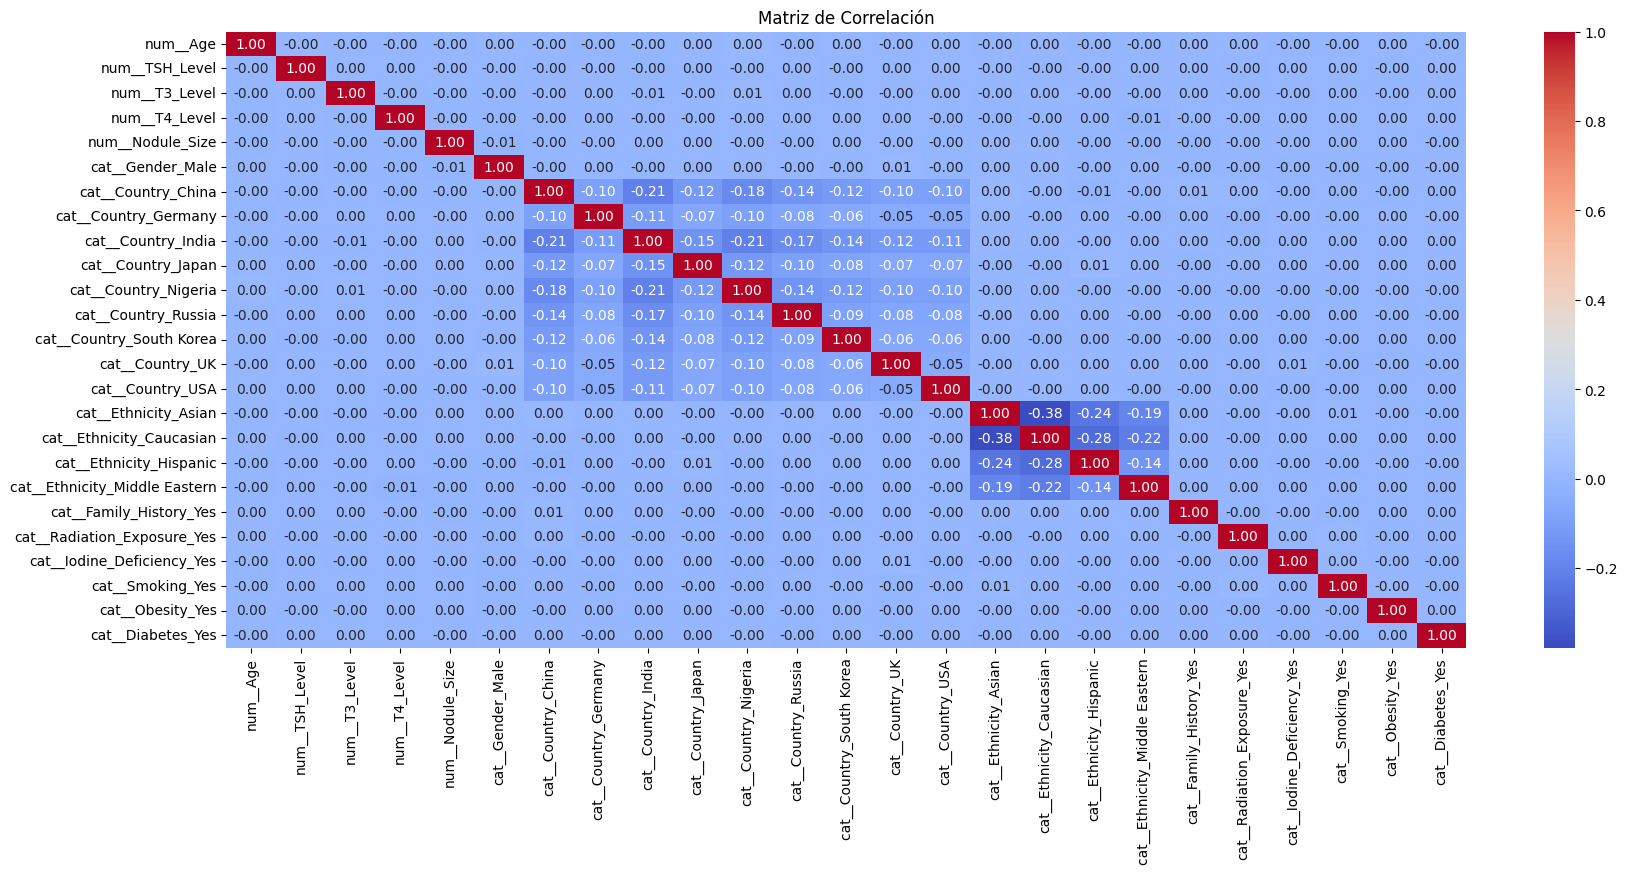

In [9]:
mat_corr=X_train_procesado.corr()
plt.figure(figsize=(20, 8))
sns.heatmap(mat_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

La matriz de correlación muestra que la mayoría de las variables presentan bajas correlaciones entre sí, indicando ausencia de multicolinealidad y confirmando que cada variable aporta información independiente al modelo.

In [10]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_procesado.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_procesado.values, i) 
                   for i in range(X_train_procesado.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

                          feature       VIF
16       cat__Ethnicity_Caucasian  2.047728
15           cat__Ethnicity_Asian  1.876673
8              cat__Country_India  1.791717
5                cat__Gender_Male  1.599525
6              cat__Country_China  1.591680
10           cat__Country_Nigeria  1.588638
17        cat__Ethnicity_Hispanic  1.528972
19        cat__Family_History_Yes  1.391897
11            cat__Country_Russia  1.391823
23               cat__Obesity_Yes  1.391627
18  cat__Ethnicity_Middle Eastern  1.347987
9              cat__Country_Japan  1.311942
21     cat__Iodine_Deficiency_Yes  1.304508
12       cat__Country_South Korea  1.277366
24              cat__Diabetes_Yes  1.231793
22               cat__Smoking_Yes  1.228893
13                cat__Country_UK  1.200212
14               cat__Country_USA  1.195319
7            cat__Country_Germany  1.192443
20    cat__Radiation_Exposure_Yes  1.162637
3                   num__T4_Level  1.000147
4                num__Nodule_Siz

Con el objetivo de evaluar la presencia de multicolinealidad entre las variables independientes, se calculó el Factor de Inflación de la Varianza (VIF) para cada una de ellas. Los valores obtenidos se encuentran en un rango comprendido entre 1.00 y 2.05, lo que indica una ausencia significativa de correlaciones fuertes entre las variables del modelo.

En particular, las variables con los valores de VIF más elevados corresponden a cat__Ethnicity_Caucasian, cat__Country_India y cat__Gender_Male, con valores cercanos a 2.0. No obstante, estos niveles se consideran aceptables y no problemáticos, ya que valores de VIF inferiores a 5 suelen interpretarse como evidencia de baja multicolinealidad.

Las variables numéricas (num__Age, num__TSH_Level, num__T3_Level, num__T4_Level, num__Nodule_Size) presentan valores de VIF muy próximos a 1, lo que confirma su independencia estadística respecto a las demás variables del modelo.

En consecuencia, no es necesario eliminar ni transformar ninguna variable por motivos de multicolinealidad, y los resultados permiten afirmar que el conjunto de datos se encuentra adecuadamente preparado para el entrenamiento de modelos de machine learning, incluyendo el modelo XGBoost y sus variantes con técnicas de balanceo (SMOTE y ADASYN).

In [11]:
X_train.to_csv('data/X_train.csv', index=False)
X_train_procesado.to_csv('data/X_train_procesado.csv', index=False)
y_train.to_csv('data/y_train.csv' ,index=False)
X_test.to_csv('data/X_test.csv' ,index=False)
y_test.to_csv('data/y_test.csv' ,index=False)

Este código exporta todos tus conjuntos de datos a archivos .csv dentro de la carpeta data/, para mantener copias limpias y reutilizables en futuras ejecuciones o análisis